In [17]:
from google.cloud import bigquery
from google.cloud import storage
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from decimal import *
from calendar import monthrange, month_abbr
import cartopy as ctp
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io import shapereader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io
import base64
import pygrib
import math
import netCDF4
import pytz
import cmocean
import seaborn as sns
from sklearn.metrics import mean_squared_error, confusion_matrix, mean_poisson_deviance
import sklearn.decomposition as skd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
import matplotlib.dates as mdates
from pytz import timezone, all_timezones
from scipy.stats import spearmanr, pearsonr
import scipy.signal as signal
from scipy.interpolate import interp1d
from taylor_diagram import TaylorDiagram
import statsmodels.api as sm
import os
import difflib
import folium
from folium.plugins import MarkerCluster, BeautifyIcon
from PIL import Image, ImageDraw
import warnings
import properscoring as ps
import numba
import pprint
from geopy.distance import geodesic
import pvlib


In [2]:
def get_guasti(fname, dstart, dend):

    # Load the dataset
    colnames = ['Data di guasto','OdL padre','Scatto','Rete','Impianto','Cavo',
                'Tratto cavo / da cabina elemento di rete presunto sede di guasto',
                'Tipo','da cabina','a cabina','Numero Nodo GIS - Solo rete 23 Kv giunti 12/20',
                'Priorità','Criticità','Fase lavorativa','Ricerca guasto','Impresa scavo','Riparazione',
                'Indirizzo dell\'intervento','Causa accertata','Intervento eseguito','Data rientro',
                'Note esercizio','Note fasi lavorative','Mese guasto','Mese riparazione','Anno',
                'Raggruppamento causa accertata','Origine','Agregazione impianto','verifica data']
    dataset = pd.read_excel(fname, sheet_name='Monitoraggio', header=None, names=colnames)

    # Convert the 'Data di guasto' column to datetime
    dataset['Data di guasto'] = pd.to_datetime(dataset['Data di guasto'], format='%d/%m/%Y', errors='coerce')
    dataset['Mese guasto'] = pd.to_datetime(dataset['Mese guasto'], format='%B', errors='coerce').dt.month

    # localize to Europe/Rome
    dataset['Data di guasto'] = dataset['Data di guasto'].dt.tz_localize('Europe/Rome')

    # filter 
    dataset = dataset[(dataset['Data di guasto'].dt.date >=dstart) & (dataset['Data di guasto'].dt.date <= dend)]

    # fill missing values in 'Causa accertata' with 'NON ACCERTATA'
    dataset['Causa accertata'] = dataset['Causa accertata'].fillna('NON ACCERTATA')

    # remove some causes
    irrelevant_causes=['NO GUASTO', 'COMPETENZA ENEL', 'PROVA DI TENSIONE OK', 'RIFACIMENTO GIUNTI 20KV']
    dataset = dataset[~dataset['Causa accertata'].isin(irrelevant_causes)]

    # group causes
    groupcause = {'joint':['AG AUTORETRAIBILE 20kV','AG TERMO-RESTRINGENTI 20kV','AG 9kV (miscela a caldo)','AG BICOMPONENTE 9kV (miscela a freddo)',
                           'AG 23kV (vecchio tipo)','AG CAVO PRECORDATO','AG RESINA','AG AUTORETRAIBILE 30kV', 'AG AUTORETR. 30KV + CELLA'],
                  'cable':['CAVO DETERIORATO','CAVO DANNEGGIATO','CAVO INTACCATO', 'CAVO DETERIORATO + CELLA LINEA'],
                  'cabin':['CABINA','TERMINALE RAICHEM','TERMINALE VETRO','CELLA LINEA','CELLA UTENTE','TERMINALE SILICONICO','TRASFORMATORE','2962 CELLA',
                           'TERMINALI + CELLA LINEA','TERMINALI ','TERMINALI','CELLA TRAFO','TERMINALE','TERMINALE + CELLA LINEA', 'TERMINALE+CELLA',
                           'CELLA TRAFO + CELLA CONGIUNTORE'],
                  'other':['DANNI', 'DANNI DA INCENDIO','SEZIONATORE A PALO', 'NON ACCERTATA']
                  }
    dataset['Causegroup'] = dataset['Causa accertata'].apply(lambda x: 'cable' if x in groupcause['cable'] else ('cabin' if x in groupcause['cabin'] else ('joint' if x in groupcause['joint'] else 'other')))
    dataset['Causegroup'] = dataset['Causegroup'].astype('category')

    print(dataset['Causegroup'].unique())

    return dataset

In [3]:
guasti_2012_2024 = get_guasti('pri_raw_pri_2023-12-11.xlsx', dt.date(2012, 1, 1), dt.date(2024, 12, 31))
print(guasti_2012_2024.tail(10))


['cable', 'joint', 'cabin', 'other']
Categories (4, object): ['cabin', 'cable', 'joint', 'other']
                Data di guasto OdL padre Scatto  Rete   Impianto       Cavo  \
7322 2023-11-18 00:00:00+01:00   3572224    NaN  23kV      VOLTA    PV23954   
7325 2023-11-22 00:00:00+01:00   3580073    NaN  23kV  VIGENTINA    VI23926   
7326 2023-11-22 00:00:00+01:00   3580312    NaN  23kV   LAMBRATE    LA23934   
7327 2023-11-22 00:00:00+01:00   3580355    NaN  23kV   LAMBRATE       LA02   
7328 2023-11-24 00:00:00+01:00   3583944    NaN  23kV        SUD  SU250-251   
7329 2023-11-24 00:00:00+01:00   3584509    NaN  23kV  VIGENTINA    VI23178   
7330 2023-11-24 00:00:00+01:00   3584857    NaN  23kV        SUD       SU01   
7331 2023-11-25 00:00:00+01:00   3586748    NaN  23kV       TREN       TN01   
7333 2023-11-28 00:00:00+01:00   3591486    NaN  23kV    ROZZANO      RZ030   
7334 2023-11-29 00:00:00+01:00   3593867    NaN  23kV     SEGURO    SE23914   

     Tratto cavo / da cabina ele

In [4]:
def plot_distrib_daily_number_failure(guasti):
    """ Plot the daily number of failures distribution """

    # count the number of failures per day
    guasti_day = guasti['Data di guasto'].dt.date.value_counts().sort_index()

    # add missing day in the index with nan value
    idx = pd.date_range(guasti_day.index.min(), guasti_day.index.max())
    guasti_day = guasti_day.reindex(idx, fill_value=0)
    guasti_day = guasti_day.astype(int)

    # print the 10 days with the highest number of failures
    print(guasti_day.sort_values(ascending=False).head(10))

    # plot the distribution as histogram
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(guasti_day, bins=range(0, guasti_day.max()+1), color='skyblue', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Number of failures per day N')
    ax.set_ylabel('Number of days with N failures') 
    ax.set_title('Distribution of the daily number of failures (2012-2023)')
    plt.show()
    plt.close()

2021-06-15    50
2022-06-14    41
2021-06-14    38
2015-07-06    36
2019-06-29    34
2023-06-23    33
2022-06-16    31
2021-06-17    30
2015-07-07    29
2015-07-03    29
Name: count, dtype: int32


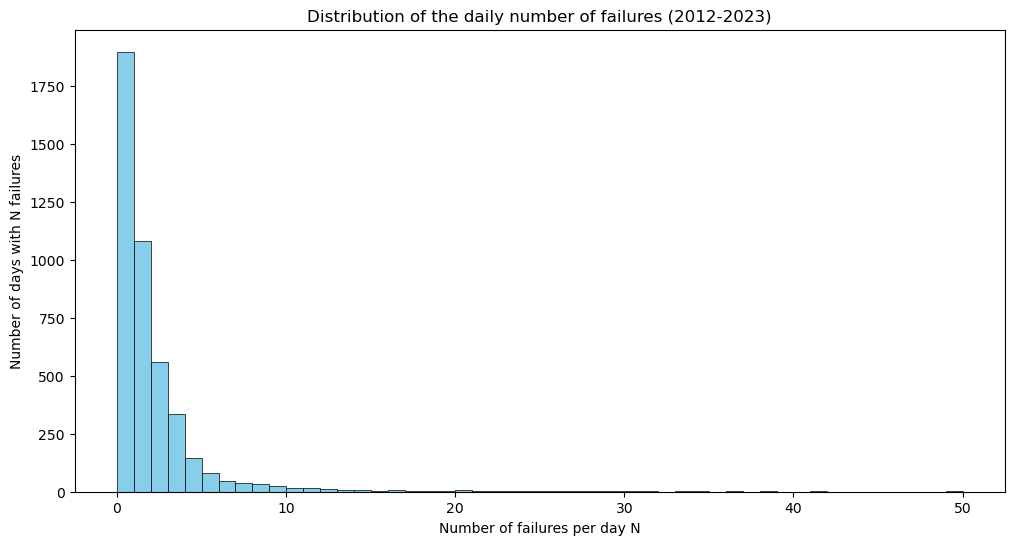

In [5]:
plot_distrib_daily_number_failure(guasti_2012_2024)

In [7]:
def get_hist_temperature(fname):

    # Load the dataset
    dataset = pd.read_csv(fname)

    # Convert the 'Data-Ora' column to datetime and change names
    dataset['Data-Ora'] = pd.to_datetime(dataset['Data-Ora'])
    dataset['Data-Ora'] = dataset['Data-Ora'].dt.tz_localize('Europe/Rome')
    dataset.rename(columns={'Data-Ora':'VALID_DATE', 'Valore Medio Giornaliero':'T_mean', ' Minimo Valore Medio Orario':'T_min', ' Massimo Valore Medio Orario':'T_max'}, inplace=True)

    # replace -999.0 with np.nan
    dataset['T_mean'] = dataset['T_mean'].replace(-999.0, np.nan)
    dataset['T_min'] = dataset['T_min'].replace(-999.0, np.nan)
    dataset['T_max'] = dataset['T_max'].replace(-999.0, np.nan)

    # drop rows with nan values
    dataset = dataset.dropna()

    return dataset

temp_brera = get_hist_temperature(r'brera_station\brera_temp_2012_2024.csv')
print(temp_brera.head())

   Id Sensore                VALID_DATE  T_mean  T_min  T_max
4        5897 2012-01-05 00:00:00+01:00     6.5    2.5   11.3
5        5897 2012-01-06 00:00:00+01:00     9.3    6.8   11.9
6        5897 2012-01-07 00:00:00+01:00     9.0    6.5   10.6
7        5897 2012-01-08 00:00:00+01:00    10.4    4.3   17.0
8        5897 2012-01-09 00:00:00+01:00     9.6    6.9   12.5


In [226]:
def prepare_data(temp, guasti):
    """ Prepare the data for the analysis """

    # count the number of failures per day
    guasti_day = guasti['Data di guasto'].dt.date.value_counts().sort_index()

    # add missing day in the index with nan value
    idx = pd.date_range(guasti_day.index.min(), guasti_day.index.max())
    guasti_day = guasti_day.reindex(idx, fill_value=0)
    guasti_day = guasti_day.astype(int)

    #date localization
    guasti_day.index = guasti_day.index.tz_localize('Europe/Rome')

    # merge the two datasets
    data = pd.merge(temp, guasti_day, left_on='VALID_DATE', right_index=True, how='inner')
    data.rename(columns={'count':'Failures'}, inplace=True)

    # set VALID_DATE as the index
    data.set_index('VALID_DATE', inplace=True)

    # add column for temperature at D-1, D-2, D-3, D-4, D-5
    data['T_mean_D-1'] = data['T_mean'].shift(1)
    data['T_mean_D-2'] = data['T_mean'].shift(2)
    data['T_mean_D-3'] = data['T_mean'].shift(3)
    data['T_mean_D-4'] = data['T_mean'].shift(4)
    data['T_mean_D-5'] = data['T_mean'].shift(5)

    # temperature min and max
    data['T_min_D-1'] = data['T_min'].shift(1)
    data['T_min_D-2'] = data['T_min'].shift(2)
    data['T_min_D-3'] = data['T_min'].shift(3)
    data['T_min_D-4'] = data['T_min'].shift(4)
    data['T_min_D-5'] = data['T_min'].shift(5)

    data['T_max_D-1'] = data['T_max'].shift(1)
    data['T_max_D-2'] = data['T_max'].shift(2)
    data['T_max_D-3'] = data['T_max'].shift(3)
    data['T_max_D-4'] = data['T_max'].shift(4)
    data['T_max_D-5'] = data['T_max'].shift(5)

    # and for the number of failures D-1, aggregated over the last 14 days, and annual
    data['Failures_D-1'] = data['Failures'].shift(1)
    data['Failures_D-14'] = data['Failures'].rolling(window=14).sum()
    data['Failures_annual'] = data['Failures'].rolling(window=365).sum()

    # solar elevation with pvlib
    latitude, longitude = 45.47, 9.19   
    times = data.index + pd.Timedelta(hours=12) # azimuth at noon
    solpos = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    solpos.index = solpos.index -pd.Timedelta(hours=12)
    data['elevation'] = solpos['elevation']  

    # 4th of the mean temperature for radiation effect
    data['T_mean4'] = data['T_mean']**4
    data['T_mean4_D-1'] = data['T_mean_D-1']**4
    data['T_mean4_D-2'] = data['T_mean_D-2']**4
    data['T_mean4_D-3'] = data['T_mean_D-3']**4
    data['T_mean4_D-4'] = data['T_mean_D-4']**4
    data['T_mean4_D-5'] = data['T_mean_D-5']**4 

    # drop rows with nan values
    data = data.dropna()


    # prepare the input variables for the PCA
    list_var = [data['elevation'],
                data['T_mean'], 
                data['T_mean_D-1'], 
                data['T_mean_D-2'], data['T_mean_D-3'], data['T_mean_D-4'], data['T_mean_D-5'], 
                data['T_min'], 
                data['T_min_D-1'], 
                 data['T_min_D-2'], data['T_min_D-3'], data['T_min_D-4'], data['T_min_D-5'], 
                data['T_max'], 
                data['T_max_D-1'], 
                data['T_max_D-2'], data['T_max_D-3'], data['T_max_D-4'], data['T_max_D-5'], 
                data['T_mean4'],
                data['T_mean4_D-1'], data['T_mean4_D-2'], data['T_mean4_D-3'], data['T_mean4_D-4'], data['T_mean4_D-5'],
                #data['Failures'],
                data['Failures_D-1'], 
                data['Failures_D-14'],
                data['Failures_annual'],
                ]
    names_var = ['elevation',
                'T_mean', 
                'T_mean_D-1', 
                'T_mean_D-2', 'T_mean_D-3', 'T_mean_D-4', 'T_mean_D-5', 
                'T_min', 
                'T_min_D-1', 
                'T_min_D-2', 'T_min_D-3', 'T_min_D-4', 'T_min_D-5', 
                'T_max', 
                'T_max_D-1', 
                'T_max_D-2', 'T_max_D-3', 'T_max_D-4', 'T_max_D-5',
                'T_mean4',
                'T_mean4_D-1', 'T_mean4_D-2', 'T_mean4_D-3', 'T_mean4_D-4', 'T_mean4_D-5',
                #'Failures',
                'Failures_D-1',
                'Failures_D-14',
                'Failures_annual'
                ]
    
    target = data['Failures']
    
    # scale features
    scaler = StandardScaler()
    features = scaler.fit_transform(np.array(list_var).T) # shape (n_samples, n_features) (3815,22)


    # Split into train and test sets (preserving time order)
    n = len(features)
    test_size = 2/11 # 2 years out of 11 years
    split_idx = int(n * (1 - test_size))
    X_train, X_test = features[:split_idx], features[split_idx:]
    y_train, y_test = target.iloc[:split_idx], target.iloc[split_idx:]

    return X_train, X_test, y_train, y_test, names_var


In [227]:
X_train, X_test, y_train, y_test, names_var = prepare_data(temp_brera, guasti_2012_2024)

In [235]:
def poisson_regression(features_train, features_test, target_train, target_test, names_var, n_components):
    """ Perform a Poisson regression on the singular values of the input data with sklearn"""

    # Perform the PCA on the training set
    pca = skd.PCA(n_components=n_components)
    X_pca_train = pca.fit_transform(features_train)
    X_pca_test = pca.transform(features_test)


    ####################### print PCA results
    # Print pca
    #print(pca.components_) # the eigenvectors (directions of maximum variance)
    #print(pca.explained_variance_ratio_, sum(pca.explained_variance_ratio_)) # the eigenvalues (variances explained by each eigenvector)
    #print(pca.singular_values_) # the singular values

    # Plot the explained variance ratio
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='o', color='skyblue')
    ax1= ax.twinx()
    ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, color='purple', label='Individual Explained Variance Ratio')

    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('Explained Variance Ratio')
    plt.show()
    plt.close() 

    # Plot the first principal component loadings
    plt.figure(figsize=(10,4))
    plt.plot(range(len(pca.components_[0])), pca.components_[0], color='skyblue', label='PC1')
    plt.plot(range(len(pca.components_[1])), pca.components_[1], color='purple', label='PC2')
    plt.plot(range(len(pca.components_[2])), pca.components_[2], color='orange', label='PC3')
    plt.plot(range(len(pca.components_[3])), pca.components_[3], color='green', label='PC4')
    plt.plot(range(len(pca.components_[4])), pca.components_[4], color='red', label='PC5')
    plt.legend()
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.xlabel('Feature')
    plt.xticks(range(len(names_var)), names_var, rotation=45, ha='right')
    plt.ylabel('Loadings')
    plt.title('Feature Loadings')
    plt.show() 
    print("Sum of squared loadings for PC1:", np.sum(pca.components_[0]**2)) # should be 1

    # plot the data in the PCA space (8 first components, in a 2x4 grid)
    fig, axs = plt.subplots(2, 2, figsize=(16, 8), sharex=True, sharey=True)
    for i in range(4):
        ax = axs[i // 2, i % 2]
        ax.scatter(target_train, X_pca_train[:, i], color='blue', label='Train', alpha=0.5)
        ax.scatter(target_test, X_pca_test[:, i], color='red', label='Test', alpha=0.5)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
        ax.set_ylabel(f'PC {i+1}')
        ax.set_xlabel('Failures')
        ax.legend()

    # --- PCA Biplot ---
    def plot_pca_biplot(pca, X, feature_names=None, pc1=1, pc2=2, scale_arrows=1):
        pcs = pca.transform(X)
        plt.figure(figsize=(8, 8))
        plt.scatter(pcs[:, pc1-1], pcs[:, pc2-1], alpha=0.2, label='Samples')
        for i, (x, y) in enumerate(zip(pca.components_[pc1-1], pca.components_[pc2-1])):
            plt.arrow(0, 0, x*scale_arrows, y*scale_arrows, color='r', alpha=0.7, head_width=0.03)
            # if feature_names is not None:
            #     plt.text(x*scale_arrows*1.1, y*scale_arrows*1.1, feature_names[i], color='r', ha='center', va='center')
            # else:
            #     plt.text(x*scale_arrows*1.1, y*scale_arrows*1.1, f"Var{i+1}", color='r', ha='center', va='center')
        plt.xlabel(f'PC{pc1} ({pca.explained_variance_ratio_[pc1-1]*100:.1f}% var)')
        plt.ylabel(f'PC{pc2} ({pca.explained_variance_ratio_[pc2-1]*100:.1f}% var)')
        plt.title('PCA Biplot')
        plt.grid()
        plt.axhline(0, color='grey', lw=1)
        plt.axvline(0, color='grey', lw=1)
        plt.show()

    plot_pca_biplot(pca, features_train, feature_names=names_var, pc1=1, pc2=2, scale_arrows=1)

     # --- Correlation Circle Plot (for PC1 and PC2) ---
    plt.figure(figsize=(7,7))
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
    plt.gca().add_artist(circle)

    # Get loadings for PC1 and PC2
    pc1 = pca.components_[0]
    pc2 = pca.components_[1]
    for i in range(len(pc1)):
        plt.arrow(0, 0, pc1[i], pc2[i], color='orange', alpha=0.7, head_width=0.03, length_includes_head=True)
        if names_var is not None:
            plt.text(pc1[i]*1.08, pc2[i]*1.08, names_var[i], color='green', ha='center', va='center', fontsize=10)
        else:
            plt.text(pc1[i]*1.08, pc2[i]*1.08, f"Var{i+1}", color='green', ha='center', va='center', fontsize=10)

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.title('PCA Correlation Circle (PC1 vs PC2)')
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.grid()
    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.show()
    

    ######################### Fit Poisson regression on the training set
    pr = PoissonRegressor()
    pr.fit(X_pca_train, target_train)
    y_pred = pr.predict(X_pca_test)

    # Compute the RMSE
    rmse = np.sqrt(mean_squared_error(target_test, y_pred))

    # Compute the mean Poisson deviance
    poisson_dev = mean_poisson_deviance(target_test, y_pred)
    
    # --- Improved null model: fit a sinusoid with 1-year period using only the training set ---
    # Get time in days since start for train and test
    if hasattr(target_train, 'index') and hasattr(target_train.index, 'to_julian_date'):
        days_train = target_train.index.to_julian_date() - target_train.index.to_julian_date()[0]
    else:
        days_train = np.arange(len(target_train))
    if hasattr(target_test, 'index') and hasattr(target_test.index, 'to_julian_date'):
        days_test = target_test.index.to_julian_date() - target_train.index.to_julian_date()[0]
    else:
        days_test = np.arange(len(target_test)) + len(target_train)

    # Fit a sinusoid: y = a + b*sin(2*pi*t/T) + c*cos(2*pi*t/T)
    T = 365.25  # period in days
    omega = 2 * np.pi / T
    A_train = np.column_stack([
        np.ones_like(days_train),
        np.sin(omega * days_train),
        np.cos(omega * days_train)
    ])
    coef, _, _, _ = np.linalg.lstsq(A_train, target_train, rcond=None)
    A_test = np.column_stack([
        np.ones_like(days_test),
        np.sin(omega * days_test),
        np.cos(omega * days_test)
    ])
    null_pred = A_test @ coef

    # Compute null model deviance
    null_deviance = mean_poisson_deviance(target_test, null_pred)
    relative_improvement = 1 - poisson_dev / null_deviance

    print(f"RMSE: {rmse:.3f}")
    print(f"Mean Poisson Deviance: {poisson_dev:.3f}")
    print(f"Null Model Deviance: {null_deviance:.3f}")

    return  pca, pr, rmse, poisson_dev, null_deviance, y_pred, null_pred


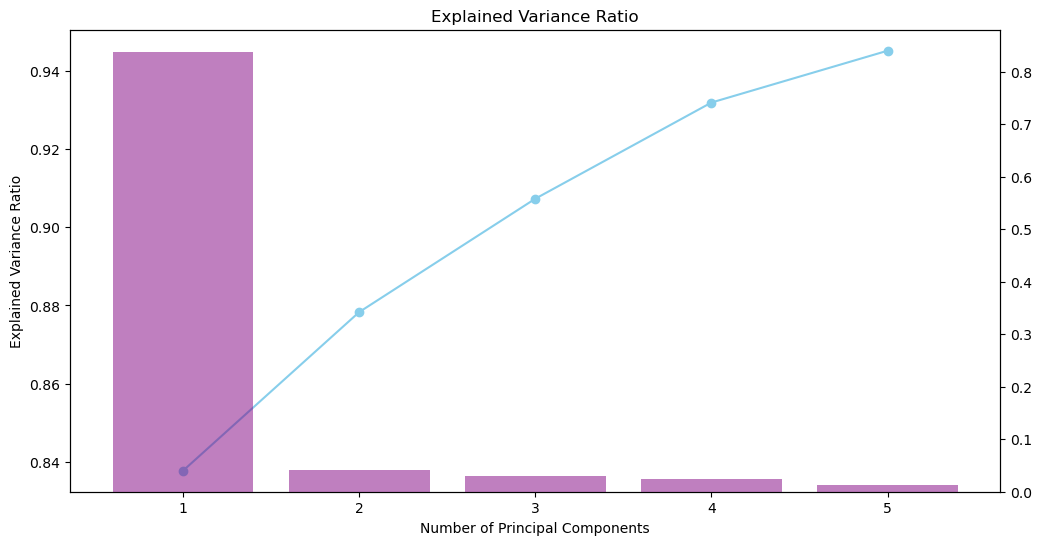

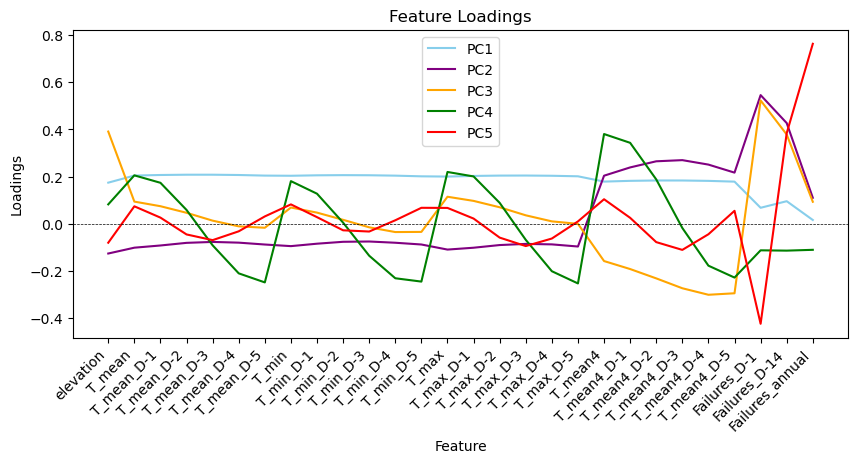

Sum of squared loadings for PC1: 0.9999999999999998


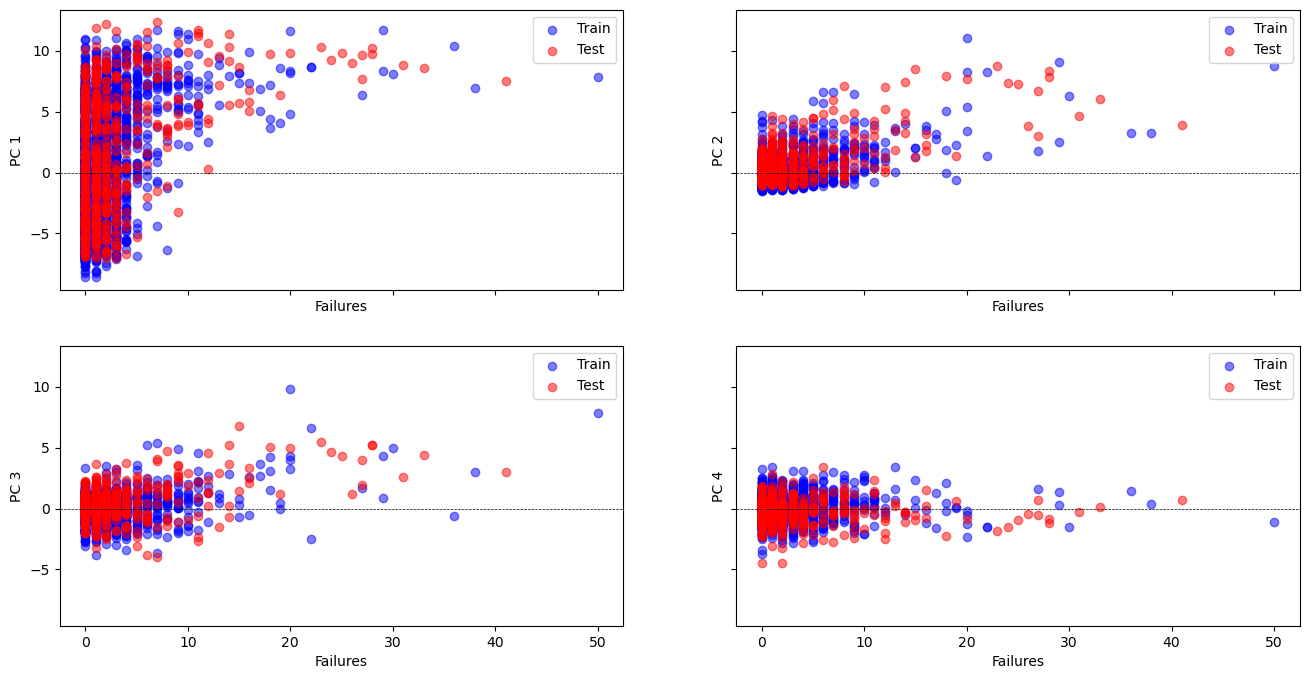

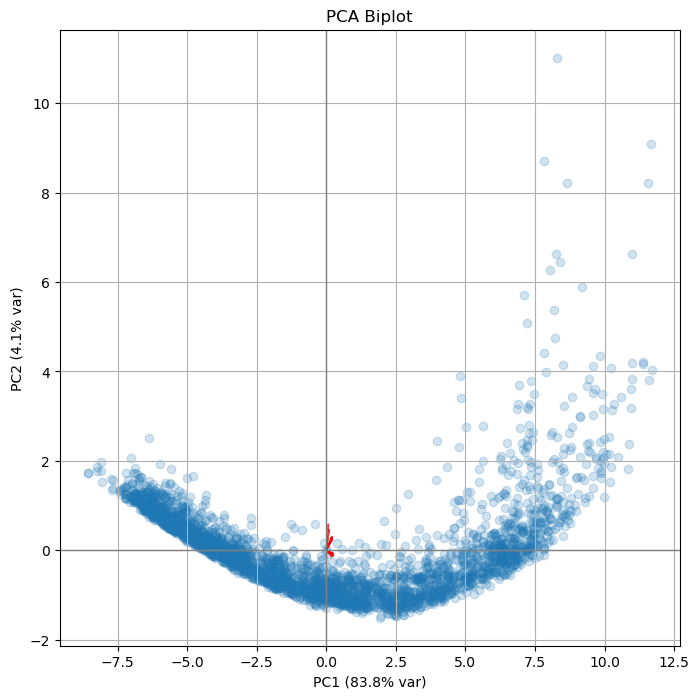

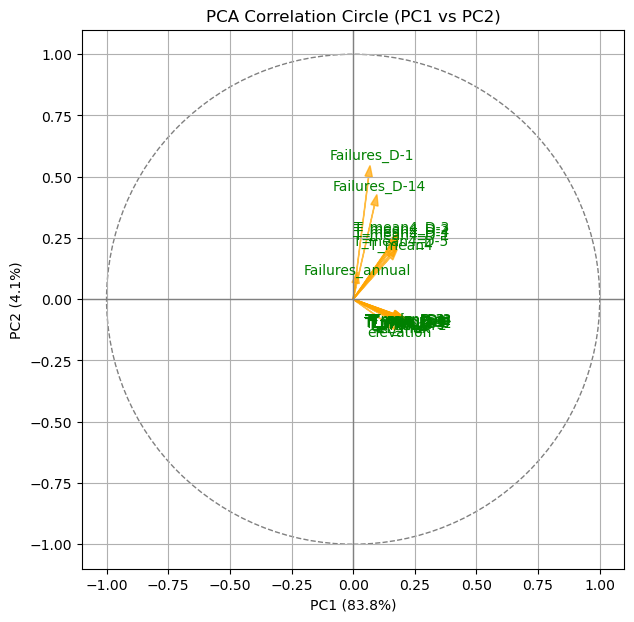

RMSE: 3.184
Mean Poisson Deviance: 2.476
Null Model Deviance: 4.115


In [236]:
pca, pr, rmse, poisson_dev, null_deviance, y_pred, null_pred =poisson_regression(X_train, X_test, y_train, y_test, names_var, n_components=5)

In [230]:
y_pred_int = np.round(y_pred).astype(int)
print(f"Predicted failures: {y_pred_int[:10]}")

Predicted failures: [1 1 1 1 1 1 1 1 1 1]


In [231]:
def plot_regression_and_test(y_train, pca, y_test, y_pred, null_pred):
    """ Plot the regression results and the test set """

    # Predict on the training set
    X_train_pca = pca.transform(X_train)
    y_train_pred = pr.predict(X_train_pca)

    # Plot the distribution of the target variable and the fitted values
    fig, ax = plt.subplots(figsize=(12, 6))
    bins= np.arange(0, 20, 1)
    sns.histplot(y_train, bins=bins, stat='probability',  color='skyblue', ax=ax)
    sns.histplot(y_train_pred, bins=bins, stat='probability', color='red', ax=ax, label='Poisson Regression Predictions')
    #sns.histplot(null_pred, bins=30, kde=True, color='black', ax=ax, label='Null Model Predictions')
    ax.set_xlabel('Number of Failures/Day')
    ax.legend()
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution Probability of the Number of Failures (Training Set)')
    plt.show()
    plt.close()


    fig, ax = plt.subplots(figsize=(12, 6))
    # plot the training set predictions
    ax.plot(y_train.index, y_train, label='Target (Train)', color='dodgerblue', alpha=0.5)
    ax.plot(y_train.index, y_train_pred, label='Poisson Regression Prediction (Train)', color='red', alpha=0.5)

    # plot the test set predictions
    ax.plot(y_test.index, y_test, label='Target', color='dodgerblue',)
    ax.plot(y_test.index, y_pred, label='Poisson Regression Prediction', color='red')
    ax.plot(y_test.index, null_pred, label='Null Model Prediction', color='k')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Failures')
    ax.set_title('Poisson Regression vs Null Model on Test Set')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

   

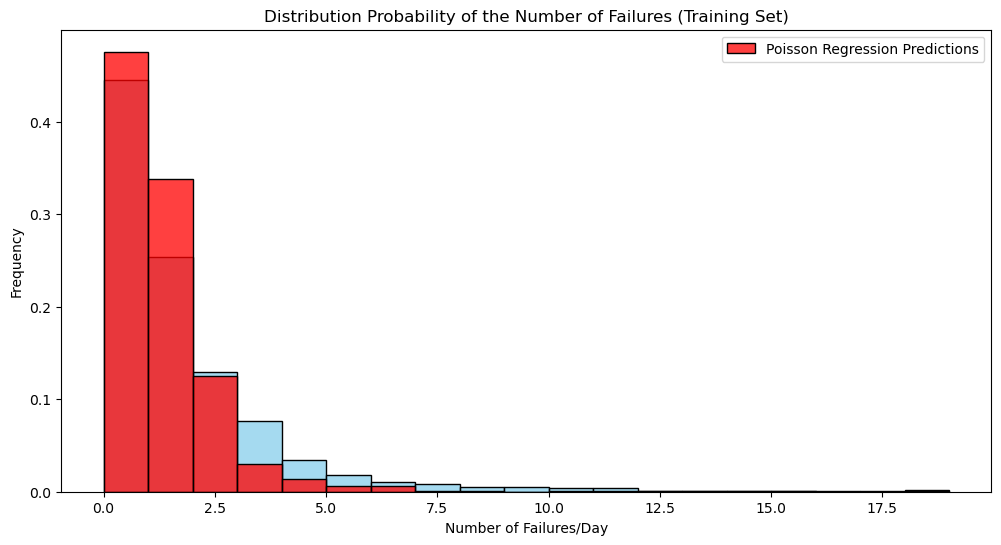

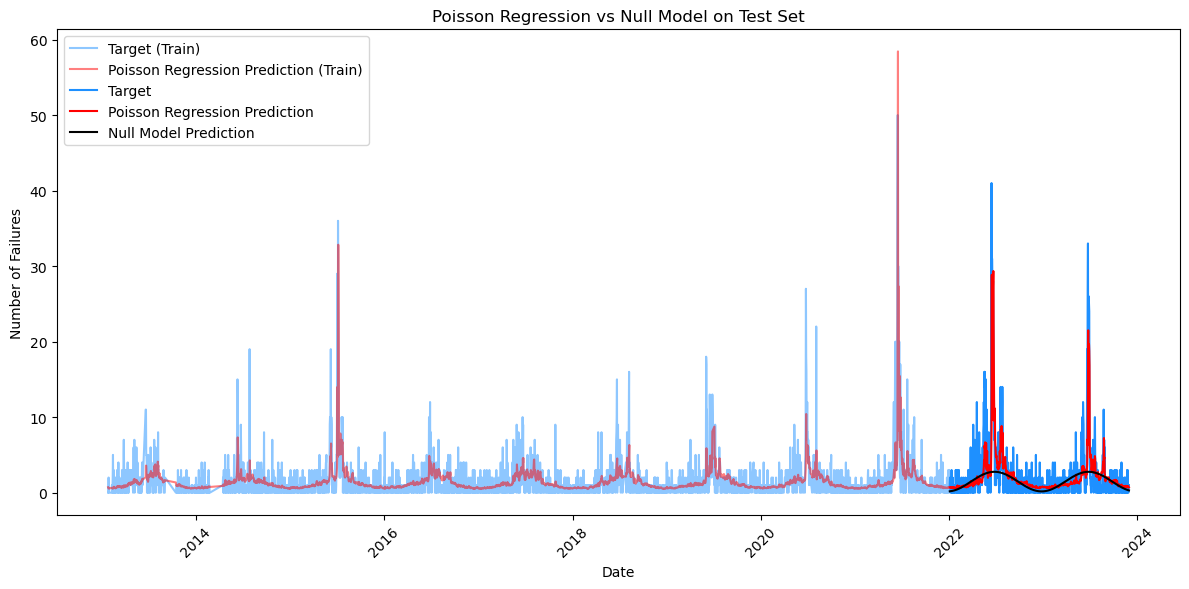

In [232]:
plot_regression_and_test(y_train, pca, y_test, y_pred, null_pred)


In [240]:

tt=(1,4)
def summ(a, b, c):
    return a + b + c
print(summ(2,*tt))

7
